In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [13]:
import numpy as np
import torch

print(np.__version__)
print(torch.__version__)

1.26.4
2.3.1


## Variational Autoencoder (VAE) 

###  VAE detailed mathematics for reparametrization trick

- Reparametrization Trick: $z \sim {\mathcal N} (\mu, \sigma)$ with mean $\mu$ and standard variation $\sigma$
    - $z\sim g_{\mu, \sigma} (\epsilon) = \mu + \epsilon \sigma$ with $\epsilon \sim {\mathcal N} (0,1)$

- Gradient ($\nabla$) and backpropagation
    - Let us consider the expectation $\mathbb{E}$ and probability density $p$
    
    -  $\mathbb{E}_{p(x)} [f(x)] = \int_x p(x) f(x) dx$

    - Leibniz integral rule:    $\mathbb{E}_{p(z)} [f_\theta(z)] =\int_z p(z) f_\theta(z) dz $
        
        - Minimizing the loss function: $\nabla_\theta \mathbb{E}_{p(z)} [f_\theta(z)] = \nabla_\theta \int_z p(z) f_\theta(z) dz =  \int_z p(z) \nabla_\theta f_\theta(z)  dz = \mathbb{E}_{p(z)} [\nabla_\theta f_\theta (z)] $


    - Goal minimization of complex parameter:   $\mathbb{E}_{p_\theta(z)}[f_\theta(z)] $
        
        -  $\nabla_\theta \mathbb{E}_{p_\theta(z)}[f_\theta(z)] = \nabla_\theta [\int_z p_\theta (z) f_\theta(z) dz]=  \int_z[\nabla_\theta p_\theta (z) f_\theta(z) dz]=  \int_z[ p_\theta (z)  \nabla_\theta f_\theta(z) dz]+\int_z [ f_\theta(z)  \nabla_\theta  p_\theta (z)   dz] =  \mathbb{E}_{p_\theta(z)} [\nabla_\theta f_\theta (z)] + \underbrace{\int_z[ f_\theta (z)  \nabla_\theta p_\theta(z) dz]}_\text{complicated for derivative -> reparametrization trick helps }$


    - Reminder  $g_\theta(\epsilon, x) =z$ and $\epsilon \sim {\mathcal N}(0,1)$ with x being input,  $z$ is latent space, and f(x) is a function need to be backpropagated
    

    -  $\mathbb{E}_{p_\theta} (z) [f_\theta(z)]  = \mathbb{E}_{p(\epsilon)} [f_\theta (g_\theta(\epsilon,x))] $

    -  $\nabla_\theta  \mathbb{E}_{p_\theta} (z) [f_\theta (z)] = \nabla_\theta \mathbb{E}_{p(\epsilon)} [f_\theta(g_\theta (\epsilon,x))] = \underbrace{\mathbb{E}_{p(\epsilon)} [\nabla_\theta  f_\theta(g_\theta (\epsilon,x)) ]}_\text{the function is differenciable with epsilon}$

    - Backpropagation $f->z->x(\mu, \sigma, \epsilon)$. Here, noise $\epsilon$ is sampled through stochsatic process whereas f, z, x  are deterministic.


### Key functioning

**Encoder:** Maps image $\rightarrow$ Latent space: $x \rightarrow (\mu, \sigma)$

**Reparameterization trick:** $z=\mu +\sigma\cdot \epsilon$ it allows backpropagation through stochastic Gaussian Distribution 

**Decoder:** Reconstruct image; $z\rightarrow x$

**Loss function:** Loss = Reconstruction Loss + KL Diveregence


    - CNN learns filters (deterministic)

    - VAE learns distribution of images

    - Latent space becomes continuous + smooth


- **Training:** Learns digit distribution

- **Laatent space:** 2D visualization of learned structure

- **Reconstruction:**  input $\rightarrow$ output reconstruction

- **Generation:** Creates new digits from noise


**Key Idea:**  VAE learns: $p(z|x)$, $p(x|z)$ -> mapping + a probabilistic representation



CNN | VAE |
 --|--|
Deterministic filters| Probabilistic latent space|
Classification (reconstruction) | Generation|
Feature maps| distribution|


Epoch 1, Loss: 174.2397
Epoch 2, Loss: 126.8667
Epoch 3, Loss: 118.1441


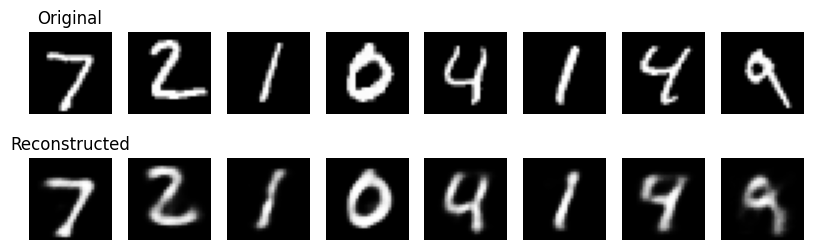

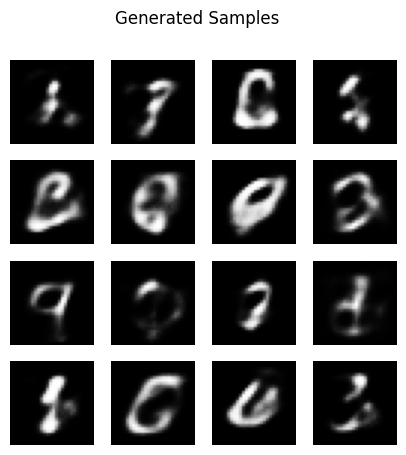

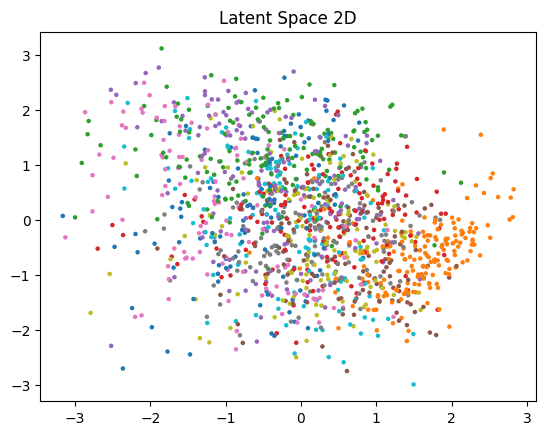

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# gpu oder cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#  VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc_mu = nn.Linear(256, 20)
        self.fc_logvar = nn.Linear(256, 20)

        self.fc2 = nn.Linear(20, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss
def loss_fn(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

# Training
epochs = 3
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")

# Reconstruction
model.eval()

x, _ = next(iter(test_loader))
x = x[:8].view(-1, 28*28).to(device)
with torch.no_grad():
    recon, _, _ = model(x)
x = x.view(-1, 1, 28, 28).cpu()
recon = recon.view(-1, 1, 28, 28).cpu()
fig, ax = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    ax[0, i].imshow(x[i][0], cmap="gray")
    ax[0, i].axis("off")
    ax[1, i].imshow(recon[i][0], cmap="gray")
    ax[1, i].axis("off")
ax[0, 0].set_title("Original")
ax[1, 0].set_title("Reconstructed")
plt.show()

# Generate samples
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = model.decode(z).view(-1, 1, 28, 28).cpu()
fig, ax = plt.subplots(4, 4, figsize=(5, 5))
for i in range(16):
    ax[i//4, i%4].imshow(samples[i][0], cmap="gray")
    ax[i//4, i%4].axis("off")
plt.suptitle("Generated Samples")
plt.show()


# Latent space visualization; 2D projection
def plot_latent():
    mus = []
    labels = []
    for x, y in test_loader:
        x = x.view(-1, 28*28).to(device)
        mu, _ = model.encode(x)
        mus.append(mu[:, :2].cpu())
        labels.append(y)
        if len(mus) > 10:
            break
    mus = torch.cat(mus)
    labels = torch.cat(labels)
    plt.scatter(mus[:,0].detach().numpy(), mus[:,1].detach().numpy(), c=labels, cmap="tab10", s=5)
    plt.title("Latent Space 2D")
    plt.show()
plot_latent()

#### For larger epocs

device= cpu
Epoch 1, Loss: 174.6162
Epoch 2, Loss: 126.6145
Epoch 3, Loss: 117.9109
Epoch 4, Loss: 114.3147
Epoch 5, Loss: 112.0491
Epoch 6, Loss: 110.6658
Epoch 7, Loss: 109.6549
Epoch 8, Loss: 108.8317
Epoch 9, Loss: 108.2721
Epoch 10, Loss: 107.7809
Epoch 11, Loss: 107.3830
Epoch 12, Loss: 107.0475


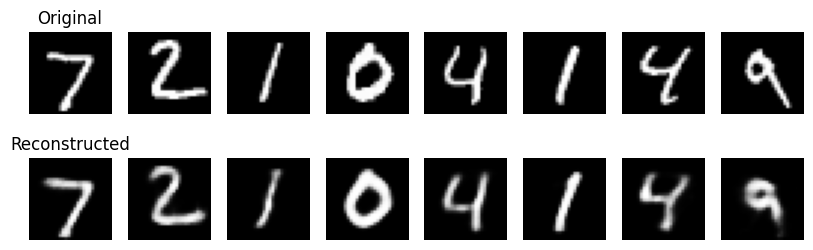

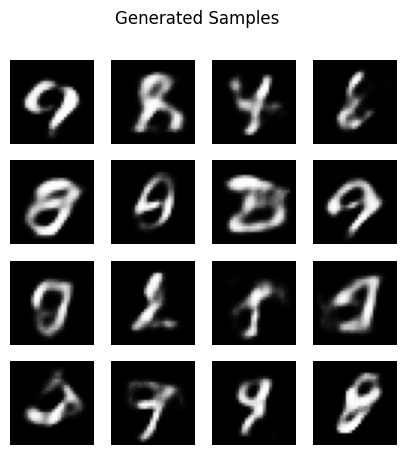

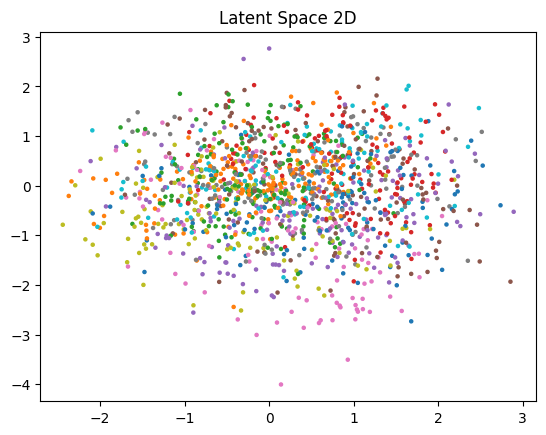

In [ ]:
#  Data
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# gpu oder cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device=',device)

#  VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc_mu = nn.Linear(256, 20)
        self.fc_logvar = nn.Linear(256, 20)

        self.fc2 = nn.Linear(20, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#  Loss
def loss_fn(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


# Training
epochs = 12
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")
    
# Reconstruction
model.eval()
x, _ = next(iter(test_loader))
x = x[:8].view(-1, 28*28).to(device)
with torch.no_grad():
    recon, _, _ = model(x)
x = x.view(-1, 1, 28, 28).cpu()
recon = recon.view(-1, 1, 28, 28).cpu()
fig, ax = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    ax[0, i].imshow(x[i][0], cmap="gray")
    ax[0, i].axis("off")
    ax[1, i].imshow(recon[i][0], cmap="gray")
    ax[1, i].axis("off")
ax[0, 0].set_title("Original")
ax[1, 0].set_title("Reconstructed")
plt.show()

# Generate samples
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = model.decode(z).view(-1, 1, 28, 28).cpu()
fig, ax = plt.subplots(4, 4, figsize=(5, 5))
for i in range(16):
    ax[i//4, i%4].imshow(samples[i][0], cmap="gray")
    ax[i//4, i%4].axis("off")
plt.suptitle("Generated Samples")
plt.show()

# Latent space visualization; 2D projection
def plot_latent():
    mus = []
    labels = []
    for x, y in test_loader:
        x = x.view(-1, 28*28).to(device)
        mu, _ = model.encode(x)
        mus.append(mu[:, :2].cpu())
        labels.append(y)
        if len(mus) > 10:
            break
    mus = torch.cat(mus)
    labels = torch.cat(labels)
    plt.scatter(mus[:,0].detach().numpy(), mus[:,1].detach().numpy(), c=labels, cmap="tab10", s=5)
    plt.title("Latent Space 2D")
    plt.show()
plot_latent()

In [ ]:

# Let's make some dark cell magic. 
from IPython.core.magic import register_cell_magic
@register_cell_magic
def write_and_run(line, cell):
    argz = line.split()
    file = argz[-1]
    mode = 'w'
    if len(argz) == 2 and argz[0] == '-a':
        mode = 'a'
        print("Appended to file ", file)
    else:
        print('Written to file:', file)
    with open(file, mode) as f:
        f.write(cell.format(**globals()))        
    get_ipython().run_cell(cell)